In [2]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

In [3]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym
import joblib

import dsrl.infos as dsrl_infos
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from dsrl_model.utils.models import ExpCostModel, ContrastiveCostModel, SafeTransformerCritic, EnsembleValue

In [4]:
def load_cost_model(obs_dim, act_dim, hidden_size, path, device, is_attention=False, is_contrastive=False, horizon=-1):
    if is_attention:
        cost_model = SafeTransformerCritic(
            obs_dim=obs_dim,
            act_dim=act_dim,
            horizon=horizon,
            latent_dim=hidden_size,
            device=device
        )
    elif is_contrastive:
        cost_model = ContrastiveCostModel(
            obs_dim=obs_dim + act_dim, hidden_sizes=[hidden_size, hidden_size]
        ).to(device)
    else:
        cost_model = ExpCostModel(
            obs_dim=obs_dim + act_dim, hidden_sizes=[hidden_size, hidden_size]
        ).to(device)
    cost_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    cost_model.eval()
    return cost_model


def load_value_model(obs_dim, act_dim, hidden_size, path, device):
    value_model = EnsembleValue(
        obs_dim=obs_dim + act_dim,
        hidden_sizes=[hidden_size,],
    ).to(device)
    value_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    value_model.eval()
    return value_model

In [5]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [6]:
def get_post_processed_dataset(env, data):
    density = 1.0
    cbins, rbins = 10, 50
    max_npb, min_npb = 30, 2
    
    inpaint_ranges = ((0.0, 1.0, 0.0, 0.5),)
    
    data = env.pre_process_data(
        data_dict=data,
        inpaint_ranges=inpaint_ranges,
        density=density,
        cbins=cbins,
        rbins=rbins,
        max_npb=max_npb,
        min_npb=min_npb,
    )
    return data


def get_dataset(env, task):
    data = env.get_dataset()
    data = get_post_processed_dataset(env, data)
    return data

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [8]:
def get_neg_z(path):
    state_dict = joblib.load(path, mmap_mode="r")
    return state_dict["neg_z"]


def get_true_cost_info_data(data):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    reward_trajs, true_cost_trajs = [], []
    rewards, costs = data["rewards"], data["costs"]
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        reward_trajs.append(np.sum(rewards[start:end]))
        true_cost_trajs.append(np.sum(costs[start:end]))
    return np.array(reward_trajs), np.array(true_cost_trajs)


def get_pred_cost_info_data(data, cost_model, is_contrastive=False, norm=False, neg_z=None):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    pred_cost_trajs = []
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    if is_contrastive:
        z = cost_model(torch.cat([observations, actions], dim=1)).detach().cpu().numpy()
        neg_z = neg_z.reshape(1, -1)
        pred_costs = (np.matmul(z, neg_z.T).squeeze() + 1) / 2
    else:
        pred_costs = cost_model(
            torch.cat([observations, actions], dim=1), use_sigmoid=True
        ).detach().squeeze().cpu().numpy()
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        pred_cost_trajs.append(np.sum(pred_costs[start:end]))
    return np.array(pred_cost_trajs)


def get_attn_pred_cost_info_data(data, cost_model, horizon, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    pred_cost_trajs = []
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        o, a = observations[start:end], actions[start:end]
        batch_size = o.shape[0] // horizon
        o, a = o[:batch_size*horizon], a[:batch_size*horizon]
        o, a = o.view(batch_size, horizon, -1), a.view(batch_size, horizon, -1)
        o, a = o.permute(1, 0, 2), a.permute(1, 0, 2)
        c = cost_model(torch.cat([o,a], dim=-1), use_sigmoid=True)
        pred_cost_trajs.append(torch.sum(c).item() * horizon)
    return np.array(pred_cost_trajs)

In [9]:
def get_pred_value_info_data(data, value_cost, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)    
    start_idx = np.concatenate([[0,], dones_idx[:-1]+1])
    v1, v2 = value_cost.V(
        torch.cat([observations[start_idx], actions[start_idx]], dim=1)
    )
    pred_value_trajs = torch.max(v1, v2).detach().cpu().numpy()
    return pred_value_trajs


def discounted_cum_sum(vec, discount):
    horizon = vec.shape[0]
    value = np.zeros(vec.shape)
    value[-1] = vec[-1]
    for i in reversed(range(horizon-1)):
        value[i] = vec[i] + discount * value[i+1]
    return value


def get_cost_value(data, data_idxs, value_cost, gamma, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    costs = data["costs"]
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    true_vs, pred_vs= [], []
    for i in range(dones_idx.shape[0]):
        if i not in data_idxs:
            continue
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        o, a, c = observations[start:end], actions[start:end], costs[start:end]
        true_vs.append(discounted_cum_sum(c, gamma))
        pred_vs.append(
            torch.max(*value_cost.V(torch.cat([o, a], dim=1))).detach().cpu().numpy()
        )
    return true_vs, pred_vs    

In [10]:
def traj_binning(traj_cost, bin_size=25):
    min_cost, max_cost = traj_cost.min(), traj_cost.max()
    c = min_cost
    bins = []
    while c < max_cost:
        bins.append([])
        c = min(bin_size + c, max_cost)
    
    for idx, cost in enumerate(traj_cost):
        cost -= min_cost
        i = min(int(cost // bin_size), len(bins)-1)    
        bins[i].append(idx)
    
    return bins

In [11]:
def light_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color


def plot_pred_cost_trajectories(pred_traj_cost, bins, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    # color = "red"
    for i, bin in enumerate(bins):
        costs = pred_traj_cost[bin]
        # amount = (0.9 - 0.9/len(bins) * i)
        ax.plot(costs, [i]*len(bin), "o")
    
    ax.set_title(task_name)
    ax.set_xlabel("Predicted Cost")
    ax.set_ylabel("Binned True Cost")
    

def plot_value(true_vs, pred_vs, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    true_vs, pred_vs = np.array(true_vs), np.array(pred_vs)
    
    true_mean, true_std = np.mean(true_vs, axis=0), np.std(true_vs, axis=0)
    pred_mean, pred_std = np.mean(pred_vs, axis=0), np.std(pred_vs, axis=0)
    
    x = np.arange(len(true_mean))
    
    ax.plot(x, true_mean, label="true mean", color="red")
    ax.fill_between(x, true_mean - true_std, true_mean + true_std, color="red", alpha=0.3)
    
    ax.plot(x, pred_mean, label="pred mean", color="blue")
    ax.fill_between(x, pred_mean - pred_std, pred_mean + pred_std, color="blue", alpha=0.3)
    
    fig.legend()
    ax.set_xlabel("timesteps")
    ax.set_ylabel("cost_value")
    ax.set_title(task_name)

In [33]:
# task = "OfflineAntVelocityGymnasium-v1"
task = "OfflinePointButton1Gymnasium-v0"
device = torch.device("cpu")

gamma = 0.99

is_norm = True
norm_type = "norm" if is_norm else "no_norm"

is_attention = False
horizon = 10

is_contrastive = True
neg_z_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safepcl/{task}/{norm_type}/state.pkl"

cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safepcl/{task}/{norm_type}/cost_model_1000000.pt"
value_cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safepcl/{task}/{norm_type}/value_cost_model_1000000.pt"

Loading dataset from /home/returaj/.dsrl/datasets/SafetyPointButton1Gymnasium-v0-200-2268.hdf5


load datafile:   0%|          | 0/7 [00:00<?, ?it/s]

load datafile: 100%|██████████| 7/7 [00:11<00:00,  1.68s/it]


rmax = 41.193016052246094, rmin = 0.008822143077850342
cmax = 200.0, cmin = 0.0
before filter: traj num = 2268, transitions num = 2268000
after filter: traj num = 2268


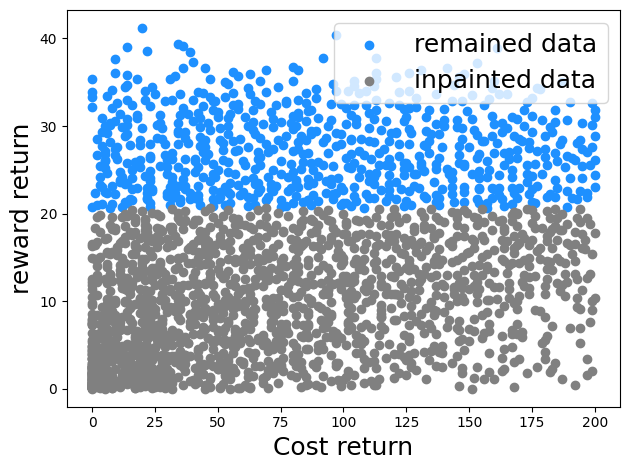

In [25]:
env, obs_dim, act_dim = get_env(task)
data = get_dataset(env, task)

In [34]:
cost_model = load_cost_model(obs_dim, act_dim, 256, cost_model_path, device,
                             is_attention=is_attention,
                             is_contrastive=is_contrastive,
                             horizon=horizon)

In [35]:
traj_reward, true_traj_cost = get_true_cost_info_data(data)
cost_bins = traj_binning(true_traj_cost)

In [36]:
neg_z = None
if is_contrastive:
    neg_z = get_neg_z(neg_z_path)

if is_attention:
    pred_traj_cost = get_attn_pred_cost_info_data(data, cost_model, horizon=10, norm=is_norm)
else:
    pred_traj_cost = get_pred_cost_info_data(data, cost_model,
                                             norm=is_norm,
                                             is_contrastive=is_contrastive,
                                             neg_z=neg_z)

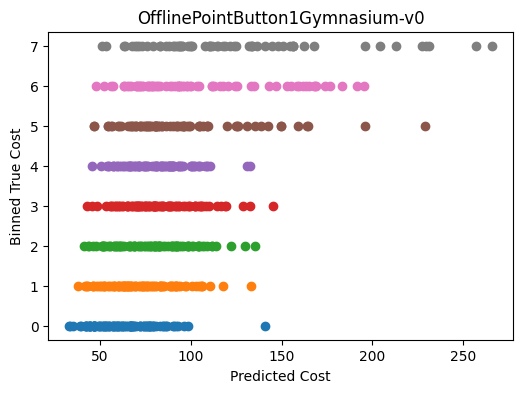

In [37]:
plot_pred_cost_trajectories(pred_traj_cost, cost_bins, task_name=task)

In [30]:
value_model = load_value_model(obs_dim, act_dim, 256, value_cost_model_path, device)

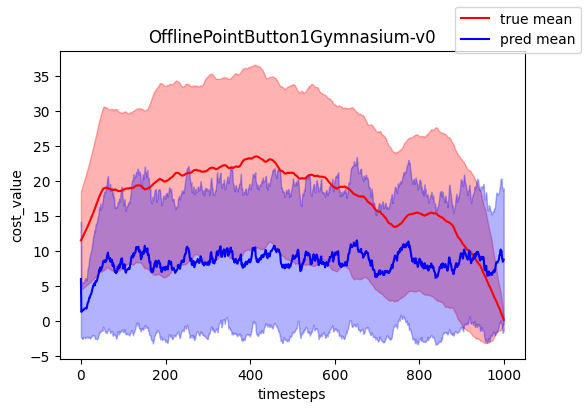

In [31]:
bin_idx = -1
true_vs, pred_vs = get_cost_value(data, cost_bins[bin_idx], value_model, gamma=gamma, norm=is_norm)
plot_value(true_vs, pred_vs, task_name=task)

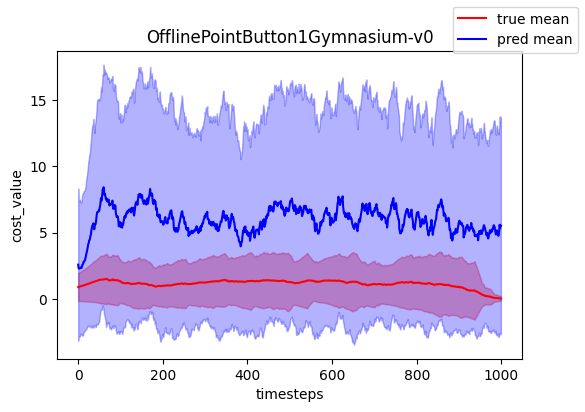

In [32]:
bin_idx = 0
true_vs, pred_vs = get_cost_value(data, cost_bins[bin_idx], value_model, gamma=gamma, norm=is_norm)
plot_value(true_vs, pred_vs, task_name=task)

In [ ]:
pred_value_cost = get_pred_value_info_data(data, value_model, norm=is_norm)

In [43]:
pred_value_cost.mean(), pred_value_cost.min(), pred_value_cost.max(), pred_value_cost.std()

(38.240517, 14.125288, 71.50286, 12.191437)